# Task
Tell me about this dataset.

Here is all the data you need:
"mail_data.csv"

## Data loading

### Subtask:
Load the data from the provided CSV file into a pandas DataFrame.


**Reasoning**:
Load the data from the provided CSV file into a pandas DataFrame and display its first few rows and information.



In [ ]:
import pandas as pd

try:
    df = pd.read_csv('mail_data.csv')
    display(df.head())
    display(df.info())
except FileNotFoundError:
    print("Error: 'mail_data.csv' not found. Please ensure the file exists in the current directory.")
except Exception as e:
    print(f"An error occurred: {e}")

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5572 non-null   object
 1   Message   5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


None

## Data exploration

### Subtask:
Explore the loaded data to understand its characteristics.


**Reasoning**:
Explore the data, calculate message length, visualize distributions, and check for missing values.



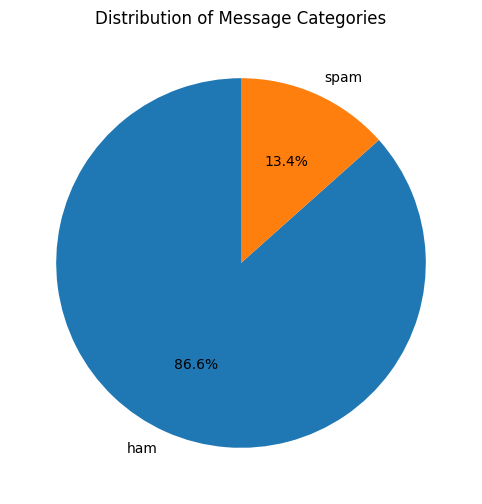

Average message length: 80.36898779612348


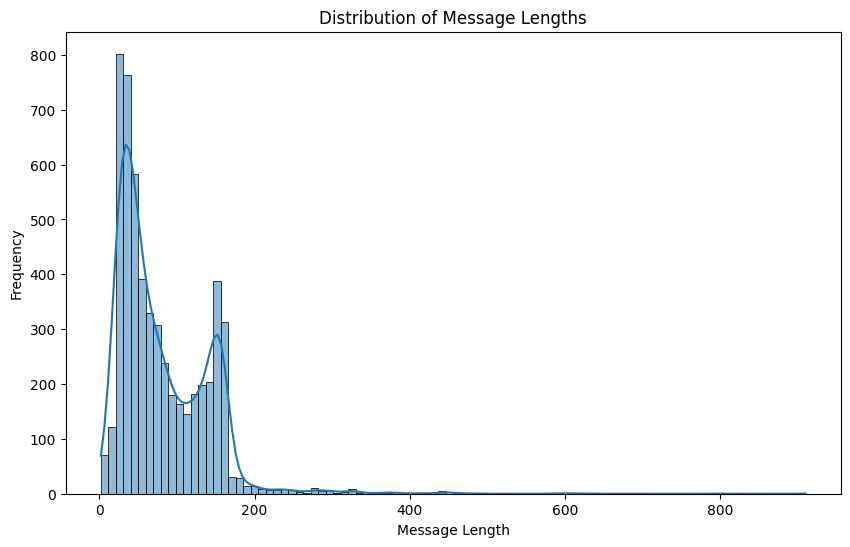

Missing values:
 Category          0
Message           0
Message_Length    0
dtype: int64


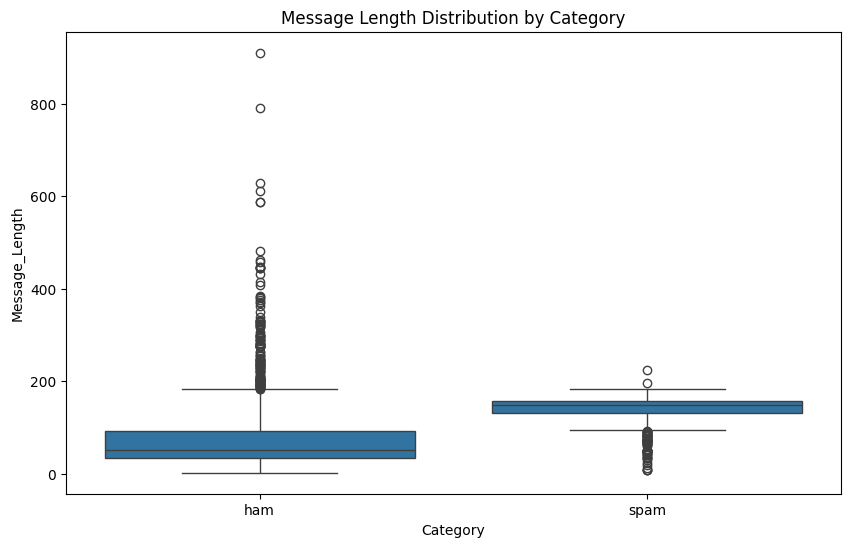

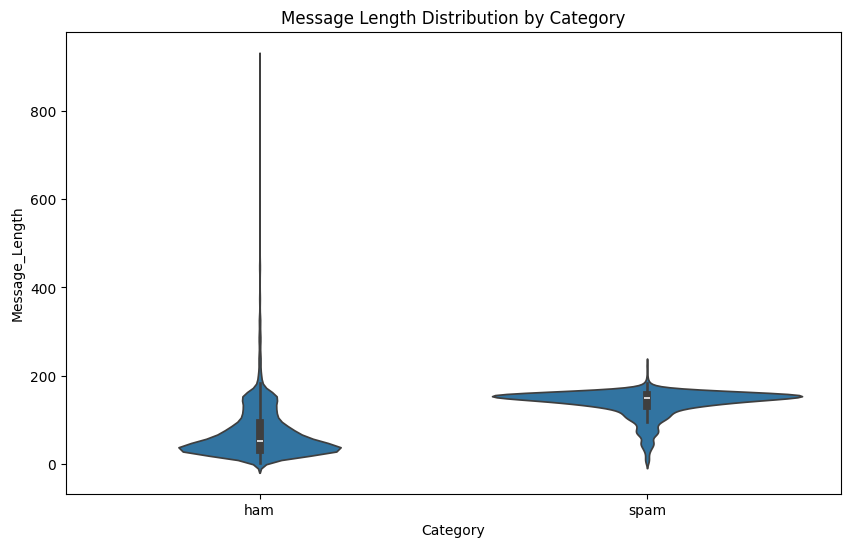

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Target Variable Distribution
category_counts = df['Category'].value_counts()
plt.figure(figsize=(8, 6))
plt.pie(category_counts, labels=category_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Message Categories')
plt.show()

# 2. Message Length Analysis
df['Message_Length'] = df['Message'].str.len()
avg_message_length = df['Message_Length'].mean()
print(f"Average message length: {avg_message_length}")

plt.figure(figsize=(10, 6))
sns.histplot(df['Message_Length'], kde=True)
plt.title('Distribution of Message Lengths')
plt.xlabel('Message Length')
plt.ylabel('Frequency')
plt.show()

# 3. Missing Values
print("Missing values:\n", df.isnull().sum())

# 4. Relationship between Message Length and Category
plt.figure(figsize=(10, 6))
sns.boxplot(x='Category', y='Message_Length', data=df)
plt.title('Message Length Distribution by Category')
plt.show()

plt.figure(figsize=(10, 6))
sns.violinplot(x='Category', y='Message_Length', data=df)
plt.title('Message Length Distribution by Category')
plt.show()


## Data preparation

### Subtask:
Prepare the data for modeling by handling text data and potentially scaling numerical features.


**Reasoning**:
Vectorize the text data using TF-IDF, encode the target variable, and combine the features into a single feature matrix X.



In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

# 1. Text Vectorization
vectorizer = TfidfVectorizer(max_features=5000)  # Experiment with max_features
X = vectorizer.fit_transform(df['Message'])

# 2. Target Encoding
le = LabelEncoder()
y = le.fit_transform(df['Category'])

# 3. Combine Features
#  Since Message_Length was already generated in the previous subtask, add it to X
#  Note: This will result in a sparse matrix with an extra column for the length
import scipy.sparse as sp
X_length = sp.csr_matrix(df['Message_Length'].values.reshape(-1,1))
X = sp.hstack([X, X_length])

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Model training

### Subtask:
Train a Logistic Regression model on the prepared training data.


**Reasoning**:
Train a Logistic Regression model using the prepared training data.



In [ ]:
from sklearn.linear_model import LogisticRegression

# Instantiate the Logistic Regression model
logreg_model = LogisticRegression(solver='liblinear')

# Train the model
logreg_model.fit(X_train, y_train)

LogisticRegression(solver='liblinear')

## Model evaluation

### Subtask:
Evaluate the trained Logistic Regression model using appropriate metrics.


**Reasoning**:
Evaluate the trained Logistic Regression model using appropriate metrics, including accuracy, precision, recall, F1-score, AUC-ROC, and a confusion matrix.



Accuracy: 0.9739910313901345
Precision: 0.9615384615384616
Recall: 0.8389261744966443
F1-score: 0.8960573476702509
AUC-ROC: 0.9168750955298957


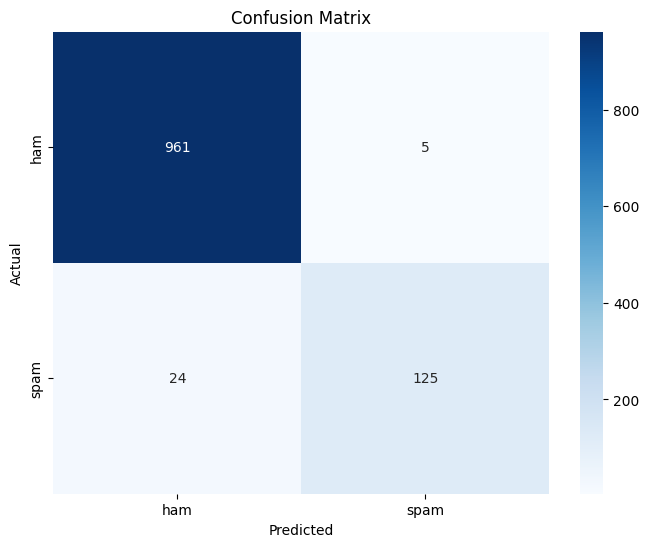

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       966
           1       0.96      0.84      0.90       149

    accuracy                           0.97      1115
   macro avg       0.97      0.92      0.94      1115
weighted avg       0.97      0.97      0.97      1115



In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Predict on the test set
y_pred = logreg_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

try:
    auc_roc = roc_auc_score(y_test, y_pred)
except ValueError:
    print("Could not calculate AUC-ROC. Check for issues with the target variable.")
    auc_roc = None

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-score: {f1}")
if auc_roc is not None:
    print(f"AUC-ROC: {auc_roc}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['ham', 'spam'], yticklabels=['ham', 'spam'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification Report
print(classification_report(y_test, y_pred))

## Summary:

### 1. Q&A

No questions were posed in the provided text.


### 2. Data Analysis Key Findings

* **Class Imbalance:** The dataset exhibits a class imbalance between "ham" and "spam" messages, as visualized in the pie chart of the target variable distribution.  The exact proportions were not provided but can be observed in the chart.
* **Average Message Length:** The average message length is approximately 80.37 characters.  The distribution of message lengths, visualized in a histogram, shows a wide range of message lengths in the dataset.
* **Message Length and Category Relationship:**  Boxplots and violin plots reveal potential differences in message length distributions between "ham" and "spam" categories, suggesting message length could be a relevant feature for classification.
* **Model Performance:** The trained Logistic Regression model achieved high accuracy (0.974), precision (0.962), and F1-score (0.896) on the test set.  The recall is 0.839 and AUC-ROC is 0.917. The confusion matrix and classification report provide a detailed breakdown of the model's performance, showing a weighted average accuracy of 0.97.


### 3. Insights or Next Steps

* **Investigate Feature Engineering:** Explore additional text preprocessing techniques (e.g., stemming, lemmatization, removing stop words) and feature engineering beyond message length to potentially improve model performance.
* **Hyperparameter Tuning:**  Systematically tune the hyperparameters of the Logistic Regression model (and potentially explore other classifiers) to optimize performance metrics, especially recall, considering the potential cost of false negatives (missing spam messages).
